In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, video_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)
        self.video_ffn = FeedForwardNetwork(video_dim, hidden_dim)

         # Projection heads for common spaces
        self.video_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.audio_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.video_to_vt = nn.Sequential(
            nn.Linear(common_space_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 3, hidden_dim),  # Only video and audio
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, audio_features):
        audio_hidden = self.audio_ffn(audio_features)

        video_hidden = self.video_ffn(video_features)

         # Project features into common spaces
        z_v_va = self.video_to_va(video_hidden)
        z_a_va = self.audio_to_va(audio_hidden)
        z_v_vt = self.video_to_vt(z_v_va)

         # Concatenate the common space outputs
        combined_embedding = torch.cat([z_v_va, z_a_va,z_v_vt], dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

In [2]:
import pandas as pd
import os
import numpy as np

# 1. Load the files
df_audio = pd.read_csv('/content/drive/MyDrive/audio_features.csv')
df_video = pd.read_csv('/content/drive/MyDrive/videomae_features.csv')

def get_clean_name(path):
    # 1. Get the filename with extension
    filename = os.path.basename(str(path))

    # 2. Separate the name from the LAST extension
    name_without_extension, extension = os.path.splitext(filename)

    return name_without_extension

# Apply cleaning to create a common key
df_audio['Clean_Link'] = df_audio['Link'].apply(get_clean_name)
df_video['Clean_Link'] = df_video['Link'].apply(get_clean_name)
df_video.rename(columns={'Target': 'Label'}, inplace=True)

# 2. INNER JOIN on the CLEANED key
df_merged = pd.merge(df_audio, df_video, on='Clean_Link', how='inner')

print(f"Successfully merged {len(df_merged)} samples.")



Successfully merged 8587 samples.


In [3]:
df_merged.head()

,Link_x,Label_x,F_0,F_1,F_2,F_3,F_4,F_5,F_6,F_7,...,V_758,V_759,V_760,V_761,V_762,V_763,V_764,V_765,V_766,V_767
0,/content/audio/Neutral_16_780.199211-786.75961...,Neutral,0.197148,0.251399,0.225539,-0.124249,-0.230679,0.173713,-0.148304,-0.055965,...,-0.200073,-0.043732,-0.166626,-0.071655,-0.027206,-0.121582,-0.070618,-0.077759,-0.029587,-0.103577
1,/content/audio/Anger_2065.964265-2070.58085_Te...,Anger,0.259752,0.280657,0.242092,-0.122128,-0.201952,0.187916,-0.180694,-0.068709,...,-0.006226,-0.029037,-0.334961,-0.256592,-0.005116,-0.146851,-0.042511,-0.040222,-0.049469,-0.056183
2,/content/audio/Neutral_16_1044.647304-1049.562...,Neutral,0.216866,0.226862,0.234272,-0.130730,-0.184365,0.139857,-0.134183,-0.065425,...,0.253174,0.014549,-0.469727,-0.079285,0.033356,-0.060211,-0.066345,-0.113220,-0.065918,-0.067444
3,/content/audio/Anger_43_2313.639905-2322.90387...,Anger,0.256735,0.244797,0.241045,-0.125785,-0.210463,0.195041,-0.158608,-0.068019,...,0.017593,-0.061707,-0.503418,-0.070068,-0.032166,-0.095947,-0.065674,-0.063354,-0.021454,-0.041382
4,/content/audio/Anger_44_294.50469-299.55833_Me...,Anger,0.220753,0.320013,0.268337,-0.131673,-0.277354,0.189542,-0.187939,-0.086221,...,0.218750,-0.002771,-0.449463,-0.220825,-0.001141,-0.023529,-0.034912,-0.098694,-0.049988,-0.054779


In [3]:
df_merged['match'] = df_merged['Label_x'] == df_merged['Label_y']

print(df_merged['match'].value_counts())

match
True     8542
False      45
Name: count, dtype: int64


In [4]:
df_merged = df_merged[df_merged['match'] == True]

In [5]:
df_merged['match'] = df_merged['Label_x'] == df_merged['Label_y']

print(df_merged['match'].value_counts())

match
True    8542
Name: count, dtype: int64


In [7]:
print(df_merged.columns)

Index(['Link_x', 'Label_x', 'F_0', 'F_1', 'F_2', 'F_3', 'F_4', 'F_5', 'F_6',
       'F_7',
       ...
       'V_759', 'V_760', 'V_761', 'V_762', 'V_763', 'V_764', 'V_765', 'V_766',
       'V_767', 'match'],
      dtype='object', length=1798)


In [6]:
# Audio features (F_ columns)
audio_cols = [col for col in df_merged.columns if col.startswith('F_')]

# Video features (V_ columns)
video_cols = [col for col in df_merged.columns if col.startswith('V_')]

# Extract data
audio_features = df_merged[audio_cols].values
video_features = df_merged[video_cols].values

# Labels
labels = df_merged['Label_x'].values


In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

label_encoder = LabelEncoder()

labels_encoded = label_encoder.fit_transform(labels)
classes = np.unique(labels_encoded)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels_encoded
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(label_encoder.classes_)
print(labels_encoded[:10])

['Anger' 'Happy' 'Love' 'Neutral' 'Sad']
[3 0 3 0 0 0 3 4 2 1]


In [8]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
video_train, video_temp, audio_train, audio_temp, y_train, y_temp = train_test_split(
    video_features,
    audio_features,
    labels_encoded,
    test_size=0.30,
    random_state=42,
    stratify=labels_encoded
)

# Second split: Temp -> Validation (15%) + Test (15%)
video_val, video_test, audio_val, audio_test, y_val, y_test = train_test_split(
    video_temp,
    audio_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [9]:
from sklearn.preprocessing import StandardScaler

# Separate scalers
scaler_video = StandardScaler()
scaler_audio = StandardScaler()

# Fit ONLY on training data
video_train = scaler_video.fit_transform(video_train)
audio_train = scaler_audio.fit_transform(audio_train)

# Transform validation and test
video_val = scaler_video.transform(video_val)
video_test = scaler_video.transform(video_test)

audio_val = scaler_audio.transform(audio_val)
audio_test = scaler_audio.transform(audio_test)

In [10]:
import torch

video_train = torch.tensor(video_train, dtype=torch.float32)
video_val = torch.tensor(video_val, dtype=torch.float32)
video_test = torch.tensor(video_test, dtype=torch.float32)

audio_train = torch.tensor(audio_train, dtype=torch.float32)
audio_val = torch.tensor(audio_val, dtype=torch.float32)
audio_test = torch.tensor(audio_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [11]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(video_train, audio_train, y_train)
val_dataset = TensorDataset(video_val, audio_val, y_val)
test_dataset = TensorDataset(video_test, audio_test, y_test)

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [13]:
audio_dim = audio_train.shape[1]
video_dim = video_train.shape[1]

model = SimpleVATTEmotionPredictor(
    audio_dim=audio_dim,
    video_dim=video_dim,
    common_space_dim=128,
    hidden_dim=256,
    num_classes = len(label_encoder.classes_)
)

In [14]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


best_val_loss = float('inf')
patience = 5  # Number of epochs to wait for improvement
counter = 0
epochs = 50

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    for v, a, y in train_loader:
        v, a, y = v.to(device), a.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(v, a)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for v, a, y in val_loader:
            v, a, y = v.to(device), a.to(device), y.to(device)
            outputs = model(v, a)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.7f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth') # Save the best version
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1, Val Loss: 1.2711
Learning Rate: 0.0001000
Epoch 2, Val Loss: 1.0453
Learning Rate: 0.0001000
Epoch 3, Val Loss: 0.9657
Learning Rate: 0.0001000
Epoch 4, Val Loss: 0.9209
Learning Rate: 0.0001000
Epoch 5, Val Loss: 0.9369
Learning Rate: 0.0001000
Epoch 6, Val Loss: 0.9361
Learning Rate: 0.0001000
Epoch 7, Val Loss: 0.9244
Learning Rate: 0.0000500
Epoch 8, Val Loss: 0.9101
Learning Rate: 0.0000500
Epoch 9, Val Loss: 0.9108
Learning Rate: 0.0000500
Epoch 10, Val Loss: 0.9525
Learning Rate: 0.0000500
Epoch 11, Val Loss: 0.9530
Learning Rate: 0.0000250
Epoch 12, Val Loss: 0.9651
Learning Rate: 0.0000250
Epoch 13, Val Loss: 0.9650
Learning Rate: 0.0000250
Early stopping triggered!


In [15]:
correct = 0
total = 0

with torch.no_grad():
    for v, a, y in test_loader:
        v, a, y = v.to(device), a.to(device), y.to(device)
        outputs = model(v, a)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 68.25%


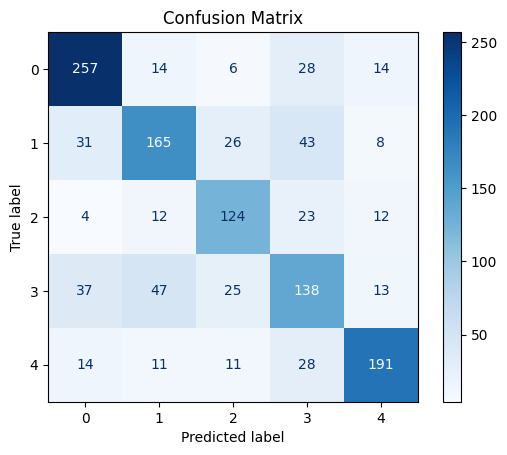

Accuracy: 68.2527
Report :
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       319
           1       0.66      0.60      0.63       273
           2       0.65      0.71      0.68       175
           3       0.53      0.53      0.53       260
           4       0.80      0.75      0.77       255

    accuracy                           0.68      1282
   macro avg       0.68      0.68      0.68      1282
weighted avg       0.68      0.68      0.68      1282



In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for v, a, y in test_loader:
        v, a = v.to(device), a.to(device)
        outputs = model(v, a)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(all_labels, all_preds)
print(f"Accuracy: {accuracy:.4f}")
print("Report :\n", report)